In [1]:
# 1.导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei'] 
# rcParams['font.sans-serif'] = ['STHeiti'] mac

In [2]:

# 2.导入数据
df = pd.read_csv(r'C:\Users\Lenovo\Desktop\课件\代码\data\house_sales.csv')

In [3]:
# 3.数据概览
print('总数据量：', len(df))
print('字段数量：', len(df.columns))
display(df.head(3))
df.info()

总数据量： 106118
字段数量： 12


,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm


<class 'pandas.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   city        106118 non-null  str  
 1   address     104452 non-null  str  
 2   area        105324 non-null  str  
 3   floor       104024 non-null  str  
 4   name        105564 non-null  str  
 5   price       105564 non-null  str  
 6   province    106118 non-null  str  
 7   rooms       104036 non-null  str  
 8   toward      105240 non-null  str  
 9   unit        105564 non-null  str  
 10  year        57736 non-null   str  
 11  origin_url  105564 non-null  str  
dtypes: str(12)
memory usage: 9.7 MB


In [4]:
# 4.数据清洗
# 4.1 删除无用的数据列
df.drop(columns='origin_url',inplace=True)

In [5]:
# 4.2检查是否有缺失值
df.isna().sum()
# 4.3 删除有缺失值的数据
df.dropna(inplace=True)

In [6]:
# 4.4 检查是否有重复值
df.duplicated().sum()
# 4.5 删除重复数据
df.drop_duplicates(inplace=True)
# 4.6 面积数据类型转换
df['area'] = df['area'].str.replace('㎡','').astype(float)
# 4.7 售价数据类型转换
df['price'] = df['price'].str.replace('万','').astype(float)
# 4.8 朝向数据类型转换
df['toward'] = df['toward'].astype('category')
# 4.9每平米数据类型转换
df['unit'] = df['unit'].str.replace('元/㎡','').astype(float)
# 4.10建造年份数据类型转换
df['year'] = df['year'].str.replace('年建','').astype(int)

In [ ]:
# 4.11 异常值的处理
# 4.11.1 房屋面积异常值处理
df = df[(df['area']<600) & (df['area']>20)]
# 4.11.2 房屋价格异常值处理 IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 -Q1
low_price = Q1-1.5*IQR
high_price = Q3+1.5*IQR
df = df[(df['price']< high_price) & (df['price']> low_price)]


In [ ]:
# 5.新数据特征构造
# 地区district
df['district'] = df['address'].str.split('-').str[0]
# 楼层的类型floor_type
df['floor_type'] = df['floor'].str.split('（').str[0].astype('category')
def fun1(str1):
    if pd.isna(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    else:
        return '未知'
df['floor_type1'] = df['floor'].apply(fun1).astype('category')
# 是否是直辖市zxs 
df['zxs'] = df['city'].apply(lambda x: 1 if x in ['北京','上海','天津','重庆'] else 0)
# 卧室的数量bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)
# 客厅的数量livingrooms
# df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int)
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype('int')
# 楼龄building_age
df['building_age'] = 2026- df['year']
# 价格的分段price_labels
df['price_labels'] = pd.cut(df['price'],bins=4,labels=['低价','中价','高价','豪华'])

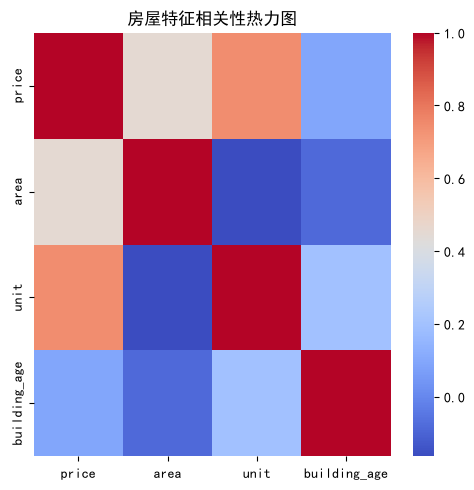

In [ ]:
# 6.问题分析与数据可视化
'''
问题编号:A1
问题:哪些变量最影响房价?面积、楼层、房间数哪个影响更大?
分析主题:特征相关性
分婚早段:无解房属备特证对房价的時性影限
分组字段:无
指标/方法:皮尔逊相关系数
'''
# 选择数值型特征
a = df[['price', 'area','unit','building_age']].corr()# 相关系数
# 房屋的相关因素排序
a['price'].sort_values(ascending=False)[1:]
# 相关性热力图
plt.figure(figsize= (5,5))
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋特征相关性热力图')
plt.tight_layout()
#df.head()

In [61]:
'''
问题编号:A2
问题:全国房价总体分布是怎样的?是否存在极端值?
主题分析：描述性统计
分析目标:概览数值型字段的分布特征
分组字段:无
指标/方法:平均数/中位数/四分位数/标准差
'''
df.describe()

,area,price,unit,year,zxs,bedrooms,livingrooms,building_age
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,0.008800,2.714444,1.848556,12.927760
std,33.995994,60.967675,5824.245273,6.019342,0.093399,0.800768,0.407353,6.019342
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,0.000000,3.000000
25%,85.005000,72.000000,7587.000000,2011.000000,0.000000,2.000000,2.000000,9.000000
50%,100.000000,103.000000,10312.000000,2015.000000,0.000000,3.000000,2.000000,11.000000
75%,123.000000,150.000000,14184.000000,2017.000000,0.000000,3.000000,2.000000,15.000000
max,470.000000,306.000000,85288.000000,2023.000000,1.000000,9.000000,12.000000,50.000000


(array([ 991., 4810., 6499., 4613., 3362., 2226., 1333., 1055.,  691.,
         555.]),
 array([  9. ,  38.7,  68.4,  98.1, 127.8, 157.5, 187.2, 216.9, 246.6,
        276.3, 306. ]),
 <BarContainer object of 10 artists>)

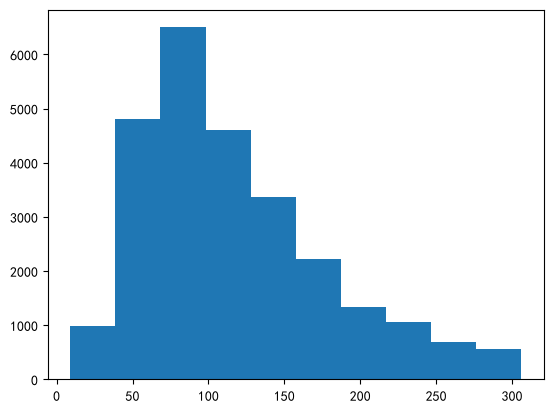

In [ ]:
# 房价分布直方图
plt.subplot(111)
plt.hist(df['price'],bins=10)

<Axes: xlabel='price', ylabel='Count'>

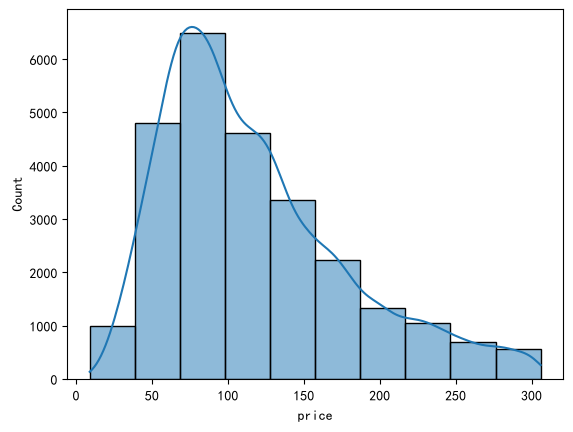

In [74]:
sns.histplot(data=df,x='price',kde=True,bins=10)

In [76]:
'''
问题编号:A6
问题:南北向是否真比单一朝向贵?贵多少?
分析主题:朝向溢价
分析目标:评估不同朝向的价格差异
分组字段:toward
指标/方法:方差分析/多重比较
'''
df['toward'].value_counts()
df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':['median'],
    'building_age':['mean'],
})

price            unit building_age
              mean median   median         mean
toward                                         
东北向     114.555333  100.0  12198.0    13.609524
东南向     115.542608  105.0  10864.0    11.951745
东向      110.158568   95.0  11421.0    13.761337
东西向      98.935099   82.0   9000.0    16.490066
北向       92.527907   75.5  11698.0    14.108527
南北向     119.472147  104.5  10000.0    13.073703
南向      114.555016  103.0  10759.0    12.551160
西北向     119.107594  105.0  12290.0    14.473684
西南向     139.711811  138.4  13333.0    14.452756
西向      102.662298   86.0  12528.0    14.385093

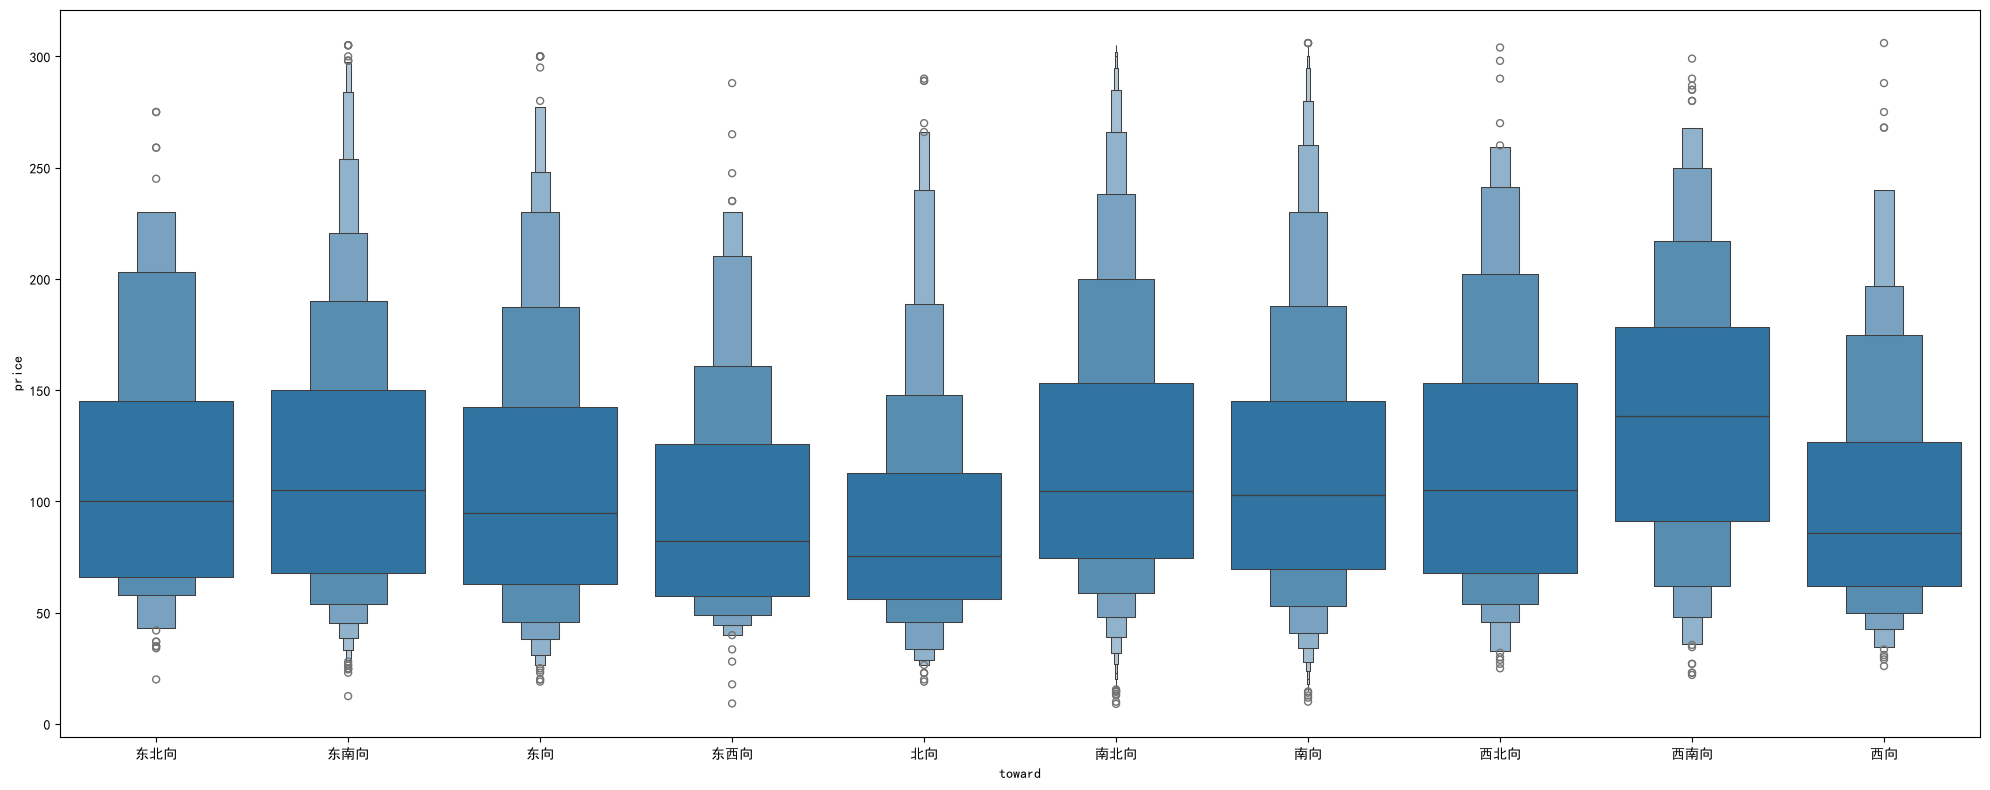

In [83]:
# 数据可视化
plt.figure(figsize=(20,8))
sns.boxenplot(x='toward', y='price', data=df)
plt.tight_layout()